Imports & global settings

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)


| Dataset   | Operating Conditions | Fault Modes | 
| --------- | -------------------- | ----------- | 
| **FD001** | 1                    | 1           | 
| FD002     | 6                    | 1           | 
| FD003     | 1                    | 2           | 
| FD004     | 6                    | 2           | 


Load CMAPSS data FDOO! (MODULAR)

In [29]:
def load_cmaps(path):
    return pd.read_csv(path, sep=r"\s+", header=None)

train_df = load_cmaps("train_FD001.txt")
test_df  = load_cmaps("test_FD001.txt")
rul_df   = load_cmaps("RUL_FD001.txt")

In [30]:
print(train_df.shape)
print(test_df.shape)
print(rul_df.shape)

train_df.head()

(20631, 26)
(13096, 26)
(100, 1)


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


| Sensor ID | Description                     |
| --------- | ------------------------------- |
| s1        | Total temperature at fan inlet  |
| s2        | Total temperature at LPC outlet |
| s3        | Total temperature at HPC outlet |
| s4        | Total temperature at LPT outlet |
| s5        | Pressure at fan inlet           |
| s6        | Total pressure at HPC outlet    |
| s7        | Total pressure at LPT outlet    |
| s8        | Physical fan speed              |
| s9        | Physical core speed             |
| s10       | Engine pressure ratio           |
| s11       | Static pressure at HPC outlet   |
| s12       | Ratio of fuel flow to Ps30      |
| s13       | Corrected fan speed             |
| s14       | Corrected core speed            |
| s15       | Bypass ratio                    |
| s16       | Burner fuel-air ratio           |
| s17       | Bleed enthalpy                  |
| s18       | Required fan speed              |
| s19       | Required core speed             |
| s20       | Static pressure at LPT outlet   |
| s21       | Fuel flow ratio                 |


In [31]:
# CMAPSS column names based on NASA documentation
cols = (
    ['engine_id', 'cycle',
     'op_setting_1', 'op_setting_2', 'op_setting_3'] +
    [f'sensor_{i}' for i in range(1, 22)]
)

train_df.columns = cols
test_df.columns  = cols

In [32]:
test_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [33]:
train_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [34]:
test_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [35]:
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Number of engines in training:", train_df['engine_id'].nunique())

train_df.head()


Train shape: (20631, 26)
Test shape : (13096, 26)
Number of engines in training: 100


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Compute RUL (Target creation)

In [36]:
def compute_rul(df):
    max_cycle = df.groupby('engine_id')['cycle'].max().reset_index()
    max_cycle.columns = ['engine_id', 'max_cycle']
    df = df.merge(max_cycle, on='engine_id')
    df['RUL'] = df['max_cycle'] - df['cycle']
    return df.drop('max_cycle', axis=1)

train_df = compute_rul(train_df)


In [37]:
# Cap RUL to reduce dominance of early-life samples
RUL_CAP = 125
train_df["RUL"] = train_df["RUL"].clip(upper=RUL_CAP)

Dataset overview (EDA)

In [38]:
print("Total records:", train_df.shape[0])
print("RUL range:", train_df['RUL'].min(), "to", train_df['RUL'].max())

train_df[['engine_id', 'cycle', 'RUL']].head()


Total records: 20631
RUL range: 0 to 125


,engine_id,cycle,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125


RUL distribution (lifespan understanding)

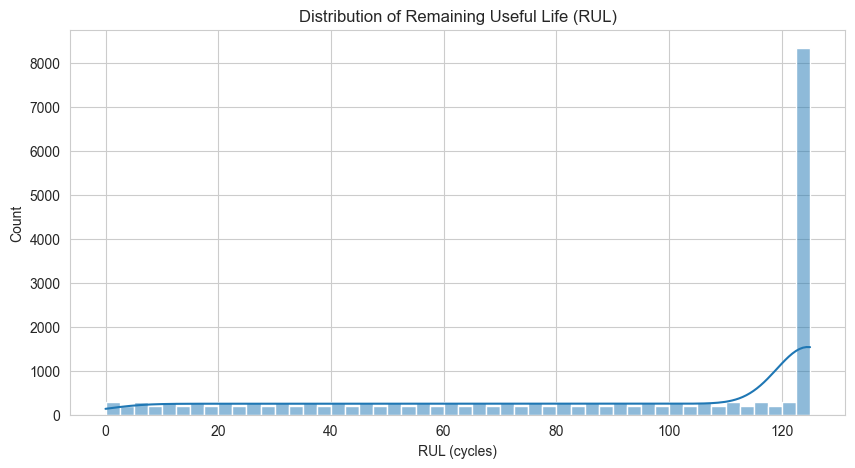

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(train_df['RUL'], bins=50, kde=True)
plt.title("Distribution of Remaining Useful Life (RUL)")
plt.xlabel("RUL (cycles)")
plt.ylabel("Count")
plt.show()

Number of cycles per engine (fleet behavior)

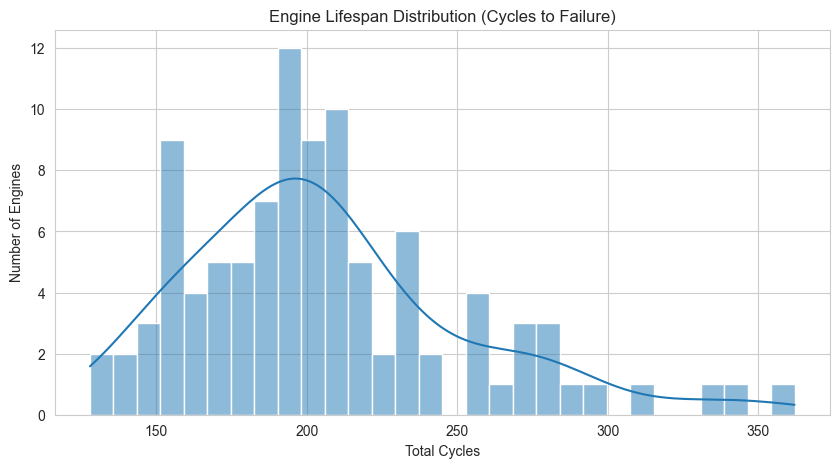

In [40]:
engine_life = train_df.groupby('engine_id')['cycle'].max()

sns.histplot(engine_life, bins=30, kde=True)
plt.title("Engine Lifespan Distribution (Cycles to Failure)")
plt.xlabel("Total Cycles")
plt.ylabel("Number of Engines")
plt.show()

Single engine RUL degradation (time dependency)

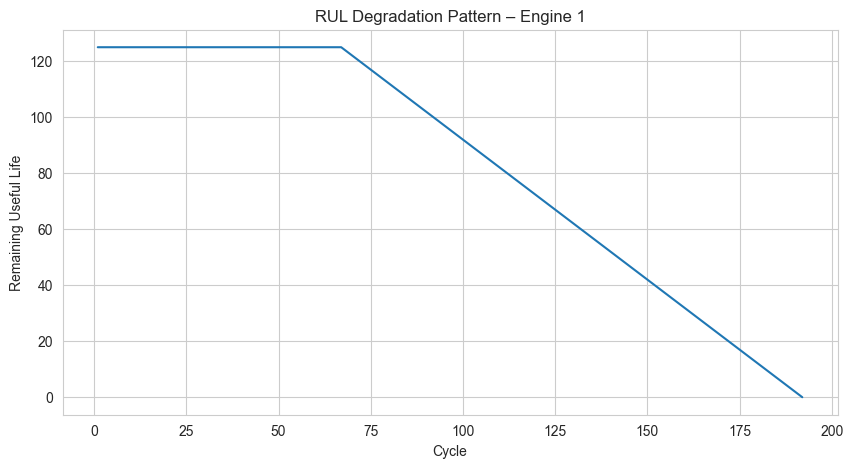

In [ ]:
engine_id = 1
engine_df = train_df[train_df['engine_id'] == engine_id]

plt.plot(engine_df['cycle'], engine_df['RUL'])
plt.title(f"RUL Degradation Pattern – Engine {engine_id}")
plt.xlabel("Cycle")
plt.ylabel("Remaining Useful Life")
plt.show()

Sensor Variability (eliminate useless sensors)

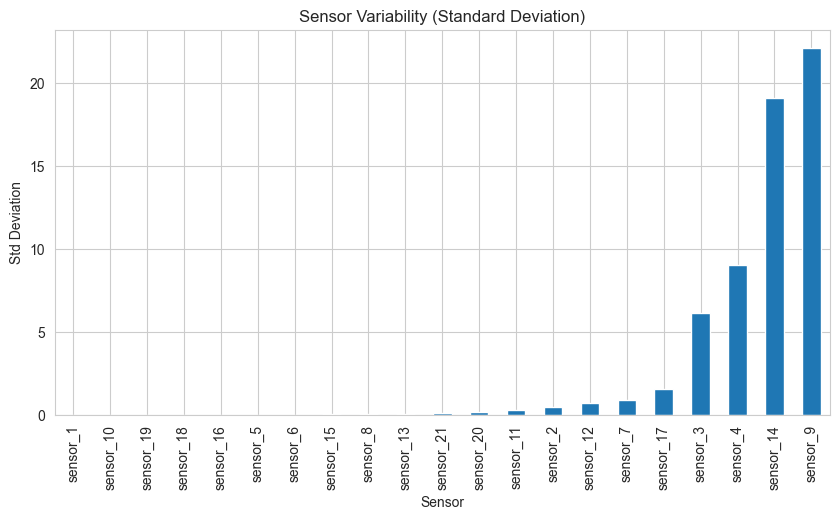

In [42]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]

sensor_std = train_df[sensor_cols].std().sort_values()

sensor_std.plot(kind='bar')
plt.title("Sensor Variability (Standard Deviation)")
plt.ylabel("Std Deviation")
plt.xlabel("Sensor")
plt.show()

Sensor distribution comparison (healthy vs near failure)

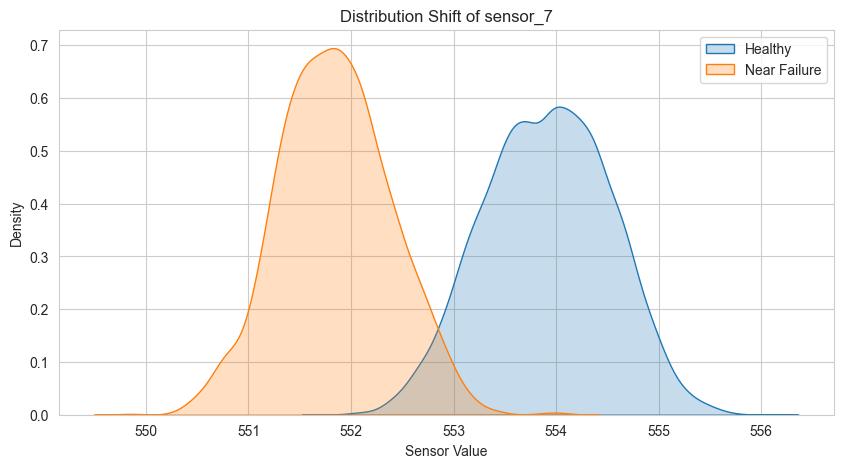

In [43]:
healthy = train_df[train_df['RUL'] > 120]
critical = train_df[train_df['RUL'] < 20]

sensor = 'sensor_7'

sns.kdeplot(healthy[sensor], label='Healthy', fill=True)
sns.kdeplot(critical[sensor], label='Near Failure', fill=True)
plt.title(f"Distribution Shift of {sensor}")
plt.xlabel("Sensor Value")
plt.legend()
plt.show()

Sensor behavior vs RUL

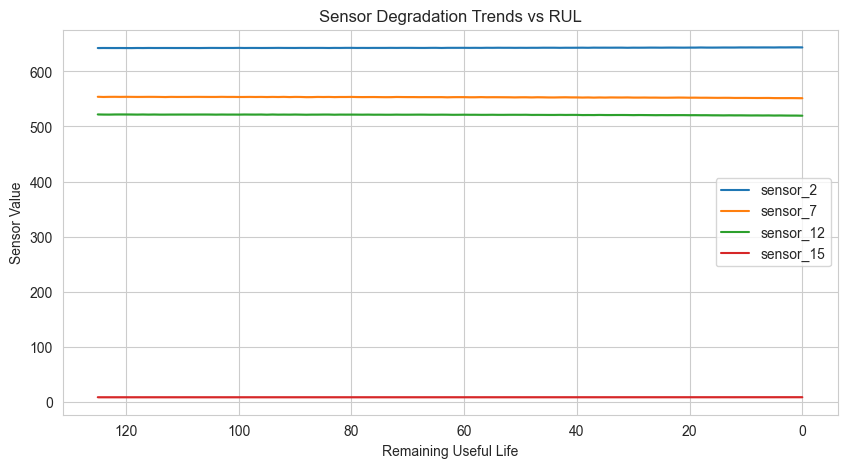

In [44]:
important_sensors = ['sensor_2', 'sensor_7', 'sensor_12', 'sensor_15']

sample_df = train_df.sample(5000, random_state=42)

for s in important_sensors:
    sns.lineplot(x='RUL', y=s, data=sample_df, label=s)

plt.gca().invert_xaxis()
plt.title("Sensor Degradation Trends vs RUL")
plt.xlabel("Remaining Useful Life")
plt.ylabel("Sensor Value")
plt.legend()
plt.show()

Correlation analysis (feature justification)

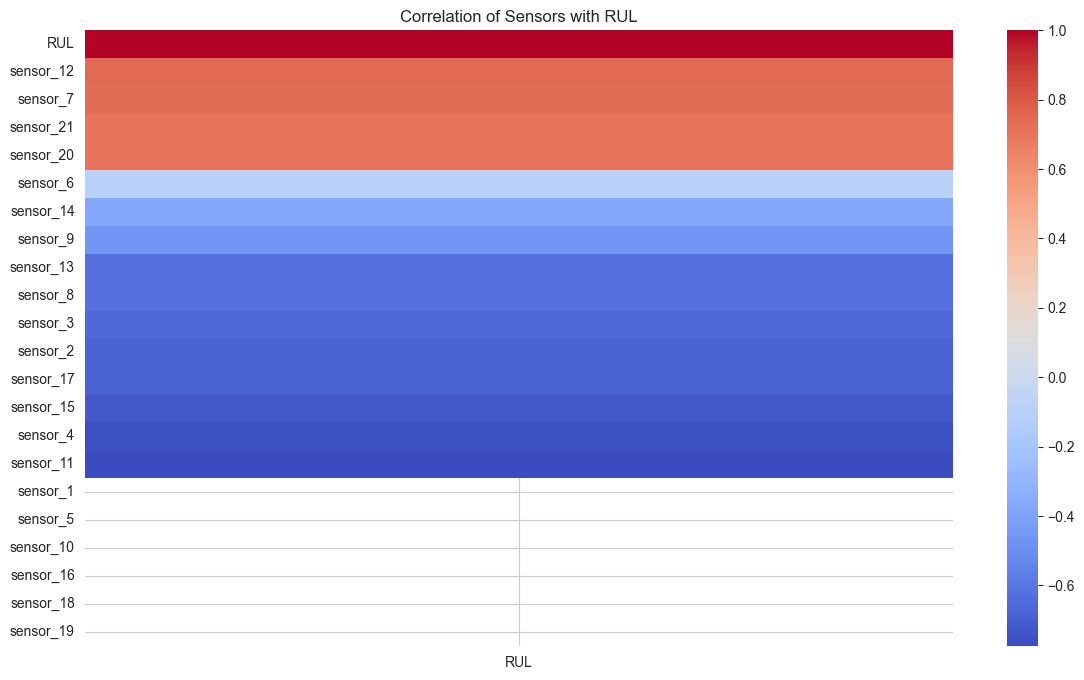

In [45]:
sensor_cols = [c for c in train_df.columns if c.startswith('sensor')]

corr = train_df[sensor_cols + ['RUL']].corr()

plt.figure(figsize=(14,8))
sns.heatmap(
    corr[['RUL']].sort_values(by='RUL', ascending=False),
    cmap='coolwarm',
    cbar=True
)
plt.title("Correlation of Sensors with RUL")
plt.show()

In [46]:
# Compute correlation with RUL
sensor_cols = [c for c in train_df.columns if c.startswith('sensor')]

corr = train_df[sensor_cols + ['RUL']].corr()
rul_corr = corr['RUL'].drop('RUL').sort_values()

Heatmap of top correlated sensors

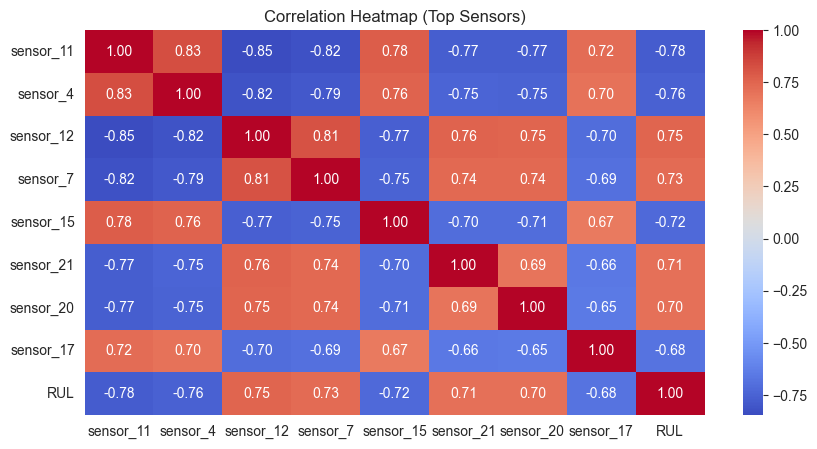

In [47]:
top_sensors = rul_corr.abs().sort_values(ascending=False).head(8).index.tolist()

sns.heatmap(
    train_df[top_sensors + ['RUL']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap (Top Sensors)")
plt.show()

Sensor trends vs RUL (fleet-level degradation)

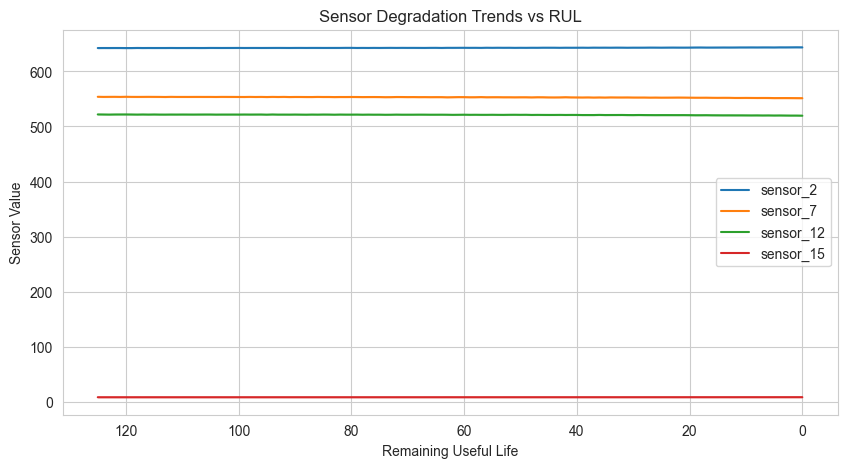

In [48]:
important_sensors = ['sensor_2', 'sensor_7', 'sensor_12', 'sensor_15']
sample_df = train_df.sample(6000, random_state=42)

for s in important_sensors:
    sns.lineplot(x='RUL', y=s, data=sample_df, label=s)

plt.gca().invert_xaxis()
plt.title("Sensor Degradation Trends vs RUL")
plt.xlabel("Remaining Useful Life")
plt.ylabel("Sensor Value")
plt.legend()
plt.show()


Sensor degradation within ONE engine (micro view)

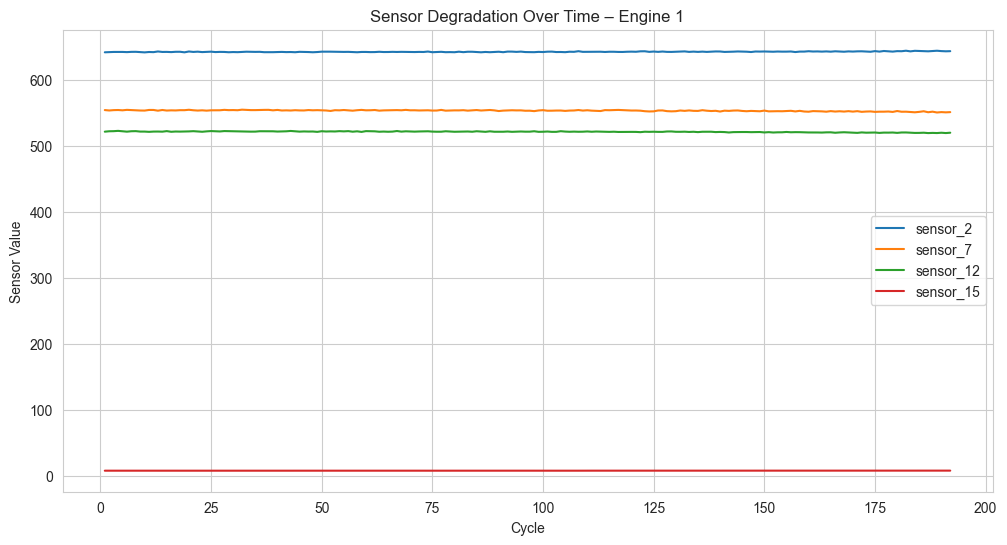

In [49]:
plt.figure(figsize=(12,6))

for s in important_sensors:
    plt.plot(engine_df['cycle'], engine_df[s], label=s)

plt.title(f"Sensor Degradation Over Time – Engine {engine_id}")
plt.xlabel("Cycle")
plt.ylabel("Sensor Value")
plt.legend()
plt.show()

Operating conditions vs RUL

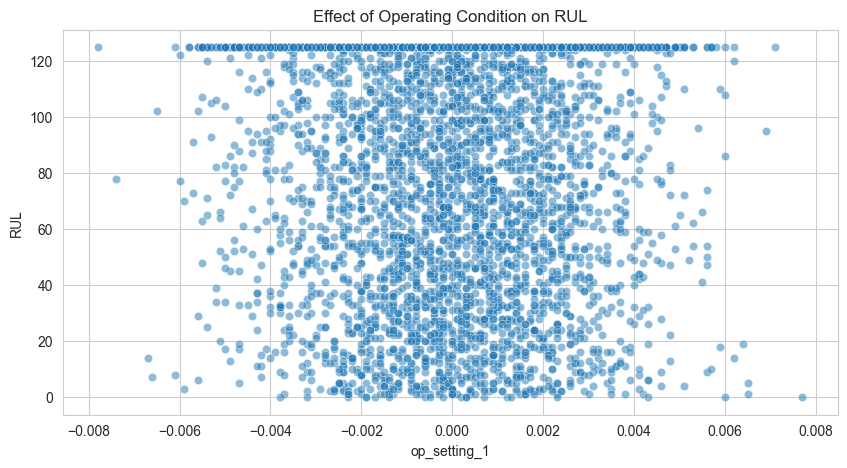

In [50]:
sns.scatterplot(
    x='op_setting_1',
    y='RUL',
    data=train_df.sample(5000),
    alpha=0.5
)
plt.title("Effect of Operating Condition on RUL")
plt.show()


Multivariate pairplot (selective, powerful)

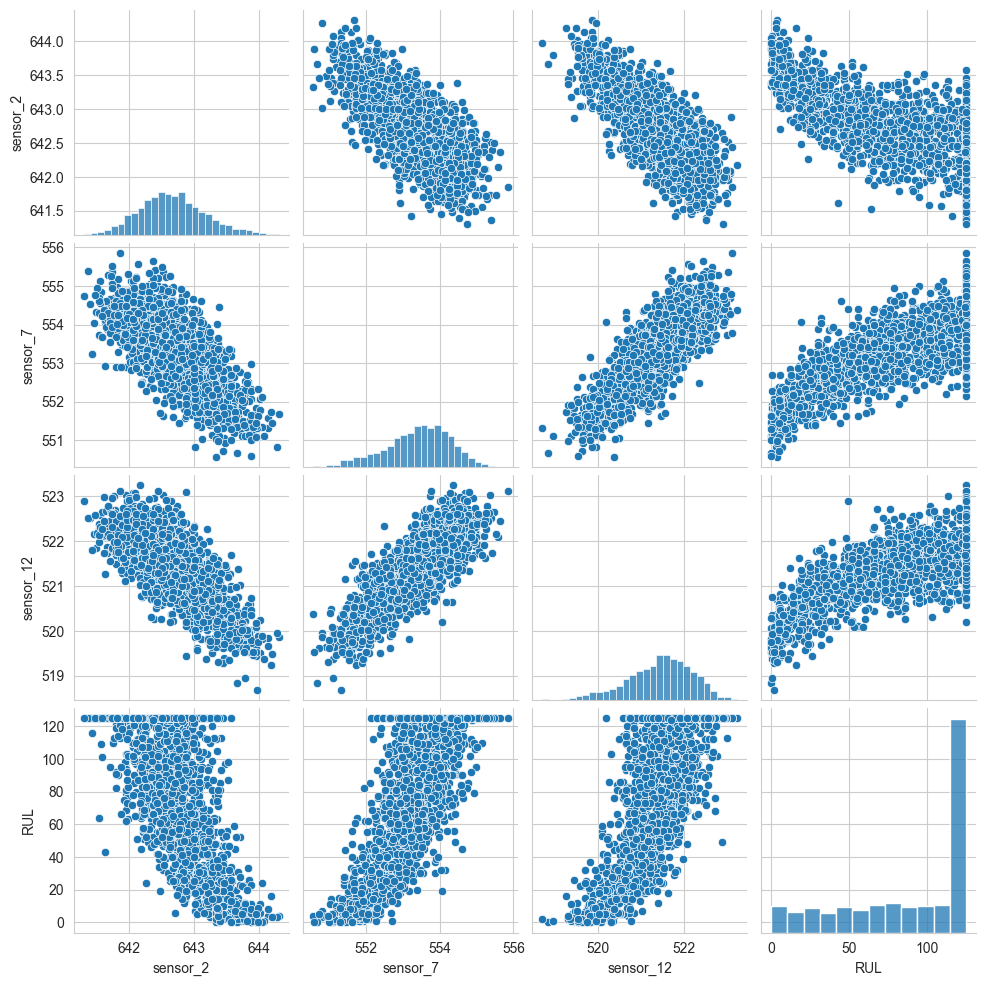

In [51]:
pair_features = ['sensor_2', 'sensor_7', 'sensor_12', 'RUL']

sns.pairplot(train_df[pair_features].sample(2000))
plt.show()

RUL trend consistency across engines

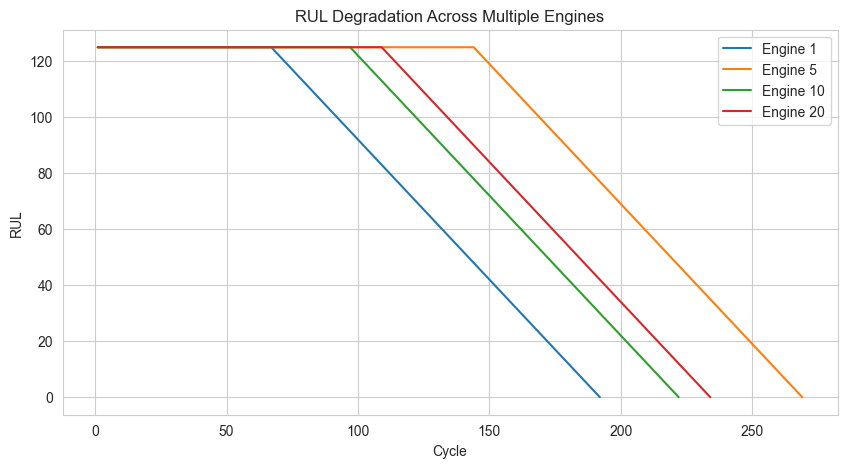

In [52]:
for eid in [1, 5, 10, 20]:
    df_e = train_df[train_df['engine_id'] == eid]
    plt.plot(df_e['cycle'], df_e['RUL'], label=f'Engine {eid}')

plt.title("RUL Degradation Across Multiple Engines")
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.legend()
plt.show()

Final EDA summary visualization (risk bands)

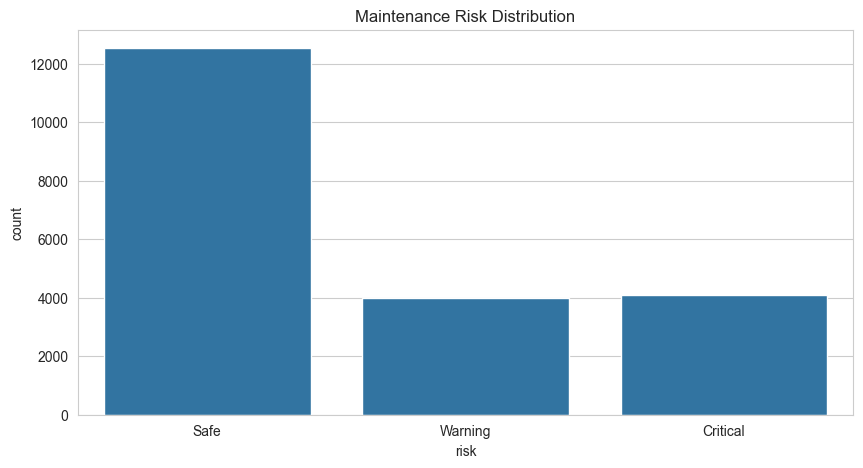

In [53]:
def risk_level(rul):
    if rul > 80:
        return "Safe"
    elif rul > 40:
        return "Warning"
    else:
        return "Critical"

train_df['risk'] = train_df['RUL'].apply(risk_level)

sns.countplot(x='risk', data=train_df)
plt.title("Maintenance Risk Distribution")
plt.show()

Single-engine RUL degradation (micro view)

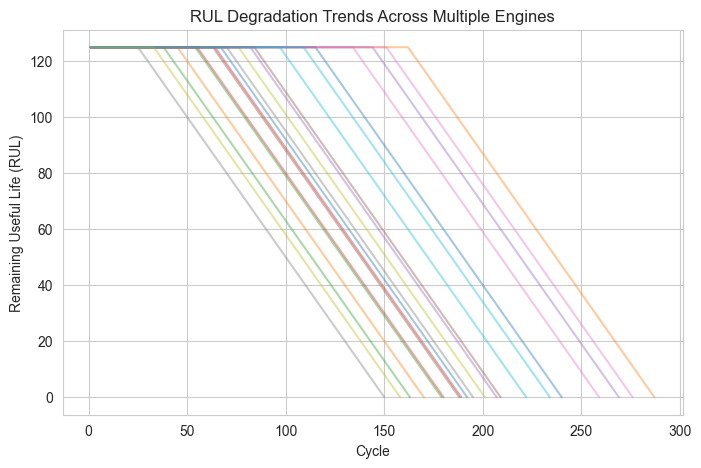

In [59]:
import matplotlib.pyplot as plt

# -------------------------------
# Resolve dataset safely
# -------------------------------
if 'df_base' in globals():
    data = df_base
elif 'train_df' in globals():
    data = train_df
elif 'df' in globals():
    data = df
else:
    raise NameError("No dataframe found. Expected df_base, train_df, or df.")

# -------------------------------
# Select a subset of engines
# -------------------------------
engine_ids = data['engine_id'].unique()[:20]  # limit for clarity

plt.figure(figsize=(8,5))

for eid in engine_ids:
    df_e = data[data['engine_id'] == eid].sort_values('cycle')
    plt.plot(df_e['cycle'], df_e['RUL'], alpha=0.4)

plt.xlabel("Cycle")
plt.ylabel("Remaining Useful Life (RUL)")
plt.title("RUL Degradation Trends Across Multiple Engines")
plt.grid(True)
plt.show()



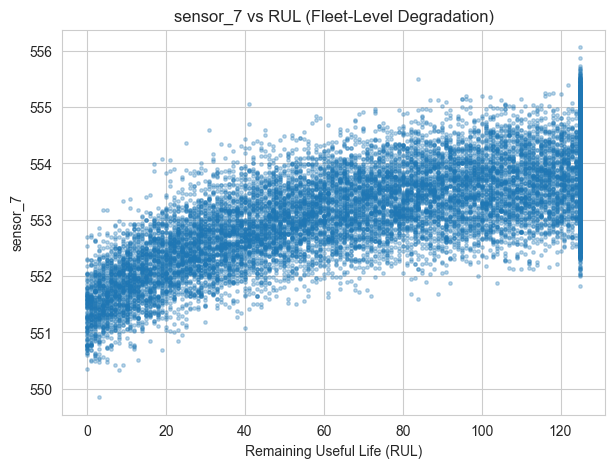

In [60]:
import matplotlib.pyplot as plt

# -------------------------------
# Resolve dataset safely
# -------------------------------
if 'df_base' in globals():
    data = df_base
elif 'train_df' in globals():
    data = train_df
elif 'df' in globals():
    data = df
else:
    raise NameError("No dataframe found. Expected df_base, train_df, or df.")

# -------------------------------
# Choose an informative sensor
# (use one you already analyzed)
# -------------------------------
sensor = 'sensor_7'   # change if needed

# -------------------------------
# Scatter plot: Sensor vs RUL
# -------------------------------
plt.figure(figsize=(7,5))
plt.scatter(
    data['RUL'],
    data[sensor],
    s=6,
    alpha=0.3
)

plt.xlabel("Remaining Useful Life (RUL)")
plt.ylabel(sensor)
plt.title(f"{sensor} vs RUL (Fleet-Level Degradation)")
plt.grid(True)
plt.show()


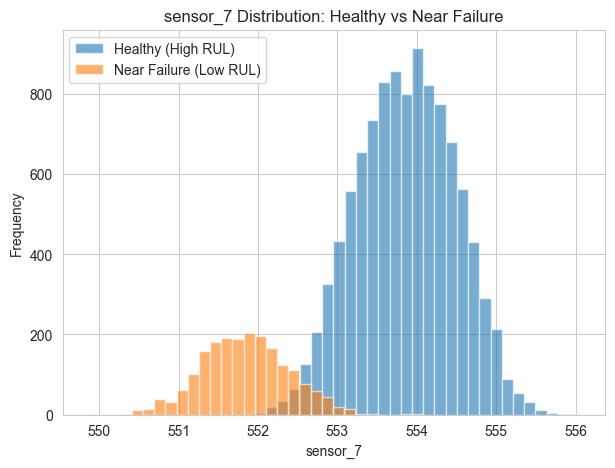

In [61]:
import matplotlib.pyplot as plt

# -------------------------------
# Resolve dataset safely
# -------------------------------
if 'df_base' in globals():
    data = df_base
elif 'train_df' in globals():
    data = train_df
elif 'df' in globals():
    data = df
else:
    raise NameError("No dataframe found. Expected df_base, train_df, or df.")

# -------------------------------
# Choose sensor and RUL thresholds
# -------------------------------
sensor = 'sensor_7'      # change if needed
healthy_thr = 100        # high RUL → healthy
failure_thr = 20         # low RUL → near failure

healthy = data[data['RUL'] > healthy_thr][sensor]
near_failure = data[data['RUL'] < failure_thr][sensor]

# -------------------------------
# Histogram comparison
# -------------------------------
plt.figure(figsize=(7,5))
plt.hist(healthy, bins=30, alpha=0.6, label="Healthy (High RUL)")
plt.hist(near_failure, bins=30, alpha=0.6, label="Near Failure (Low RUL)")
plt.xlabel(sensor)
plt.ylabel("Frequency")
plt.title(f"{sensor} Distribution: Healthy vs Near Failure")
plt.legend()
plt.grid(True)
plt.show()


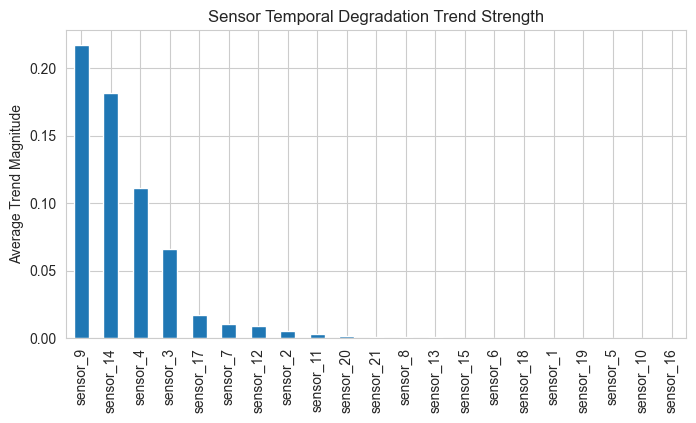

In [63]:
import numpy as np

trend_strength = {}

for sensor in sensor_cols:
    slopes = []
    for eid in data['engine_id'].unique()[:30]:  # sample engines
        df_e = data[data['engine_id'] == eid].sort_values('cycle')
        if len(df_e) > 20:
            slope = np.polyfit(df_e['cycle'], df_e[sensor], 1)[0]
            slopes.append(abs(slope))
    trend_strength[sensor] = np.mean(slopes)

trend_series = pd.Series(trend_strength).sort_values(ascending=False)

# Plot
plt.figure(figsize=(8,4))
trend_series.plot(kind='bar')
plt.ylabel("Average Trend Magnitude")
plt.title("Sensor Temporal Degradation Trend Strength")
plt.grid(True)
plt.show()


### EDA Conclusion

* #### Engine degradation is progressive 

Supported by:

“Single engine RUL degradation (time dependency)”

“RUL trend consistency across multiple engines”

These analyses show a smooth, monotonic decrease in Remaining Useful Life over cycles, confirming that degradation occurs gradually rather than abruptly.

* #### Certain sensors systematically change with RUL

Supported by:

“Sensor behavior vs RUL (fleet-level degradation)”

“Sensor distribution comparison (healthy vs near failure)”

These visualizations demonstrate consistent shifts in sensor values as failure approaches, indicating that specific sensors reliably track degradation.

* #### Degradation is time-dependent, not snapshot-based

Supported by:

“Single engine RUL degradation (time dependency)”

“Sensor degradation within ONE engine (micro view)”

These cells show that sensor values evolve over time and that identical sensor readings can represent different health states depending on historical context.

* #### Different engines follow similar degradation patterns

Supported by:

“RUL trend consistency across multiple engines”

“Sensor trends vs RUL (fleet-level degradation)”

Despite varying lifespans, engines exhibit comparable degradation trajectories, confirming the presence of generalizable patterns across assets.

* #### Sensor behavior justifies LSTM → temporal learning

Supported by:

“Sensor degradation within ONE engine (micro view)”

“Sensor trends vs RUL (fleet-level degradation)”

These analyses reveal that degradation information is encoded in sequences of sensor readings rather than individual observations, motivating the use of sequence-based models such as LSTM.